# PKCERT Task 16 – End-to-End Machine Learning Pipeline Project

**Objective:** Develop a complete end-to-end machine learning solution by applying concepts
learned throughout the internship. Build a complete ML pipeline from data preparation to model
development, evaluation, and project documentation.

- **Name:** Ahmad Haroon
- **Batch:** Batch 2
- **Domain:** AI & Software Development

**Total Marks:** 100
| Part | Assessment Area | Marks |
|---|---|---|
| A | Dataset Selection & Data Preparation | 25 |
| B | Model Development | 35 |
| C | Model Evaluation | 20 |
| D | Project Documentation | 20 |

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, RocCurveDisplay, f1_score,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
os.makedirs("models", exist_ok=True)
os.makedirs("visualizations", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## Part A – Dataset Selection & Data Preparation (25 Marks)

### A.1 Dataset

**Dataset:** [Telco Customer Churn](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv)
(IBM sample dataset, 7,043 customers of a telecom company).

**Target variable:** `Churn` — whether the customer left the company within the last month
(`Yes` / `No`). This is a **binary classification** problem.

**Features (19 predictors after dropping the ID):**
- *Demographics:* `gender`, `SeniorCitizen`, `Partner`, `Dependents`
- *Account info:* `tenure` (months with the company), `Contract`, `PaperlessBilling`,
  `PaymentMethod`, `MonthlyCharges`, `TotalCharges`
- *Services subscribed:* `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`,
  `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

`customerID` is a unique identifier with no predictive value and is dropped.

In [2]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### A.2 Data Cleaning

`TotalCharges` is loaded as `object` because a handful of brand-new customers (`tenure == 0`)
have a blank string instead of a numeric value. These are coerced to `NaN` and imputed to `0`
(no billing history yet, which is the correct value for a customer who just joined).
`customerID` is dropped, and duplicate rows are checked for. Since `customerID` was the only
unique key, any duplicate found afterwards is a coincidental match on the remaining 20 feature
columns (plausible in a dataset this categorical), not a guaranteed double-counted record — so
these rows are kept rather than dropped.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Rows with missing TotalCharges (blank string originally):", df["TotalCharges"].isna().sum())
print("Their tenure values:", df.loc[df["TotalCharges"].isna(), "tenure"].unique())

df["TotalCharges"] = df["TotalCharges"].fillna(0)
df = df.drop(columns=["customerID"])

print("Duplicate rows:", df.duplicated().sum())
print("Missing values per column:\n", df.isna().sum()[df.isna().sum() > 0])

Rows with missing TotalCharges (blank string originally): 11
Their tenure values: [0]
Duplicate rows: 22
Missing values per column:
 Series([], dtype: int64)


### A.3 Feature Engineering

Several service columns encode "no internet/phone service" as its own category, which is
redundant with `InternetService == 'No'` / `PhoneService == 'No'` — these are collapsed into a
plain `"No"` so the encoder doesn't learn a spurious extra category. Two engineered features are
added:

- `AvgMonthlySpend = TotalCharges / max(tenure, 1)` — smooths out billing-cycle noise better than
  `TotalCharges` alone.
- `TenureGroup` — bucketed tenure (new / established / loyal), since churn risk is famously
  concentrated in the first year.

In [5]:
service_cols = ["MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]
for c in service_cols:
    df[c] = df[c].replace({"No internet service": "No", "No phone service": "No"})

df["AvgMonthlySpend"] = df["TotalCharges"] / df["tenure"].replace(0, 1)
df["TenureGroup"] = pd.cut(
    df["tenure"], bins=[-1, 12, 36, 100], labels=["New (0-12mo)", "Established (1-3yr)", "Loyal (3yr+)"]
)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlySpend,TenureGroup
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,29.850000,New (0-12mo)
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,0,55.573529,Established (1-3yr)
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,54.075000,New (0-12mo)
3,Male,0,No,No,45,No,No,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,40.905556,Loyal (3yr+)
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,75.825000,New (0-12mo)


### A.4 Exploratory Data Analysis

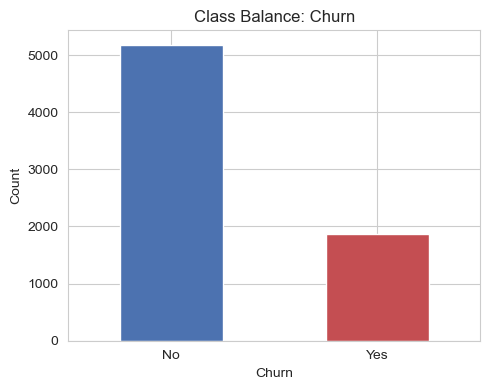

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
df["Churn"].map({0: "No", 1: "Yes"}).value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_title("Class Balance: Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("visualizations/1_class_balance.png", dpi=120)
plt.show()

print(df["Churn"].value_counts(normalize=True).rename("proportion"))

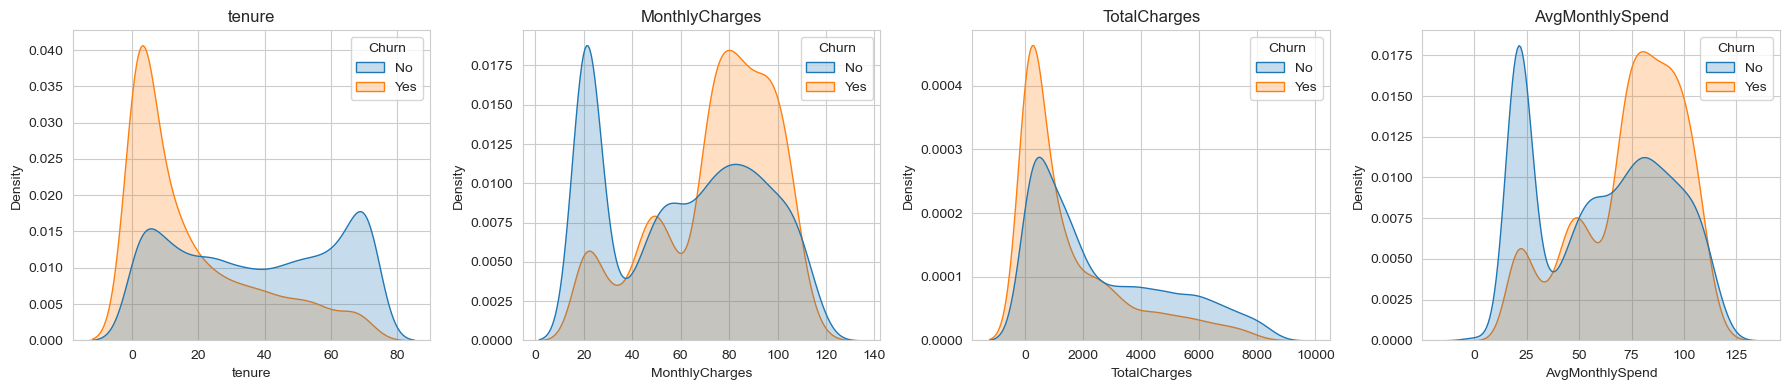

In [7]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend"]

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(data=df, x=col, hue=df["Churn"].map({0: "No", 1: "Yes"}), fill=True, ax=ax, common_norm=False)
    ax.set_title(col)
    ax.legend_.set_title("Churn") if ax.legend_ else None
plt.tight_layout()
plt.savefig("visualizations/2_numeric_distributions_by_churn.png", dpi=120)
plt.show()

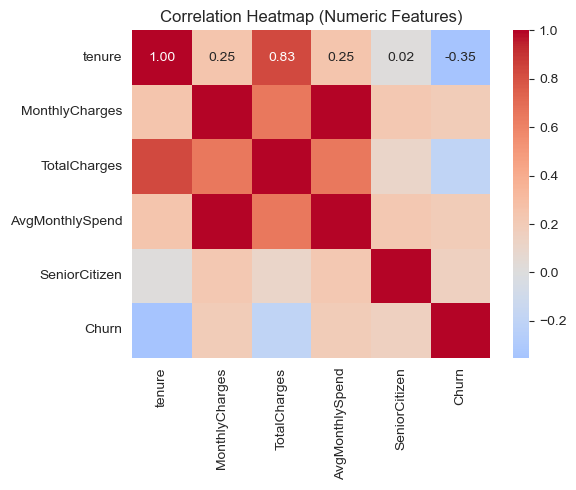

In [8]:
corr = df[numeric_cols + ["SeniorCitizen", "Churn"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("visualizations/3_correlation_heatmap.png", dpi=120)
plt.show()

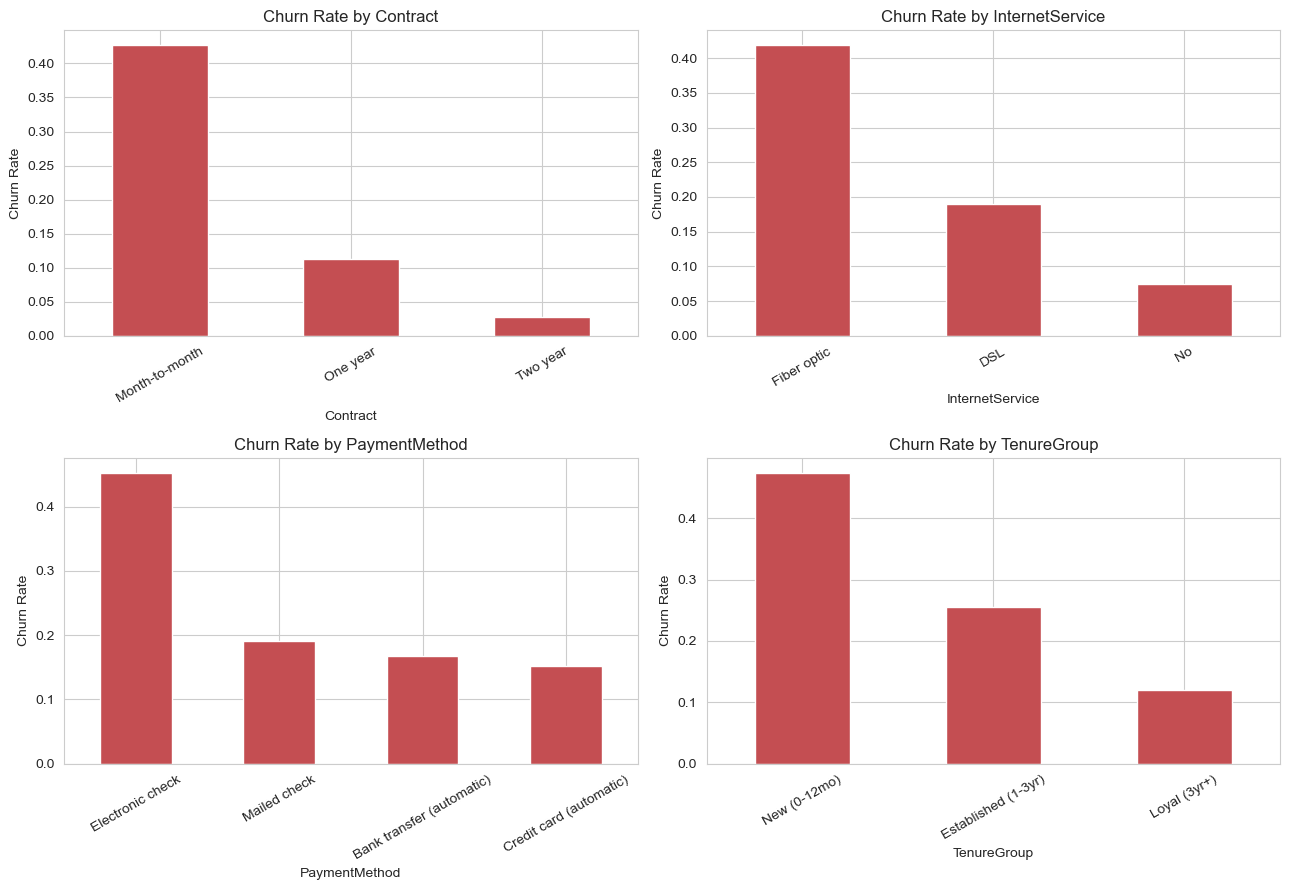

In [9]:
cat_cols_to_plot = ["Contract", "InternetService", "PaymentMethod", "TenureGroup"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cat_cols_to_plot):
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("visualizations/4_churn_rate_by_category.png", dpi=120)
plt.show()

**EDA takeaways:**
- Churn is imbalanced (~26.5% positive class) — worth tracking F1/ROC-AUC, not just accuracy.
- Short-tenure, month-to-month customers with fiber-optic internet and electronic-check payment
  churn at a much higher rate — classic "low switching cost" profile.
- `TotalCharges` correlates strongly with `tenure` (as expected, it's a running total), so the
  model doesn't need both in raw form — `AvgMonthlySpend` normalizes this.

## Part B – Model Development (35 Marks)

### B.1 Train/Test Split & Preprocessing Pipeline

Numeric features are median-imputed and standard-scaled; categorical features are most-frequent
imputed and one-hot encoded. Wrapping both in a `ColumnTransformer` inside a `Pipeline` means the
*exact same* fitted transformation is applied at train and inference time — no manual leakage risk.

In [10]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlySpend", "SeniorCitizen"]
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Train shape: (5634, 21)  Test shape: (1409, 21)
Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'SeniorCitizen']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


### B.2 Candidate Models & Cross-Validation

Three model families are compared with 5-fold stratified cross-validation on the training set:
a linear baseline (Logistic Regression, `class_weight="balanced"` to counter the imbalance) and
two tree ensembles (Random Forest, Gradient Boosting). ROC-AUC and F1 are used since accuracy is
misleading on an imbalanced target.

In [11]:
candidates = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in candidates.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["roc_auc", "f1", "accuracy"])
    results.append({
        "model": name,
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "accuracy_mean": scores["test_accuracy"].mean(),
    })

results_df = pd.DataFrame(results).sort_values("roc_auc_mean", ascending=False).reset_index(drop=True)
results_df

,model,roc_auc_mean,roc_auc_std,f1_mean,accuracy_mean
0,LogisticRegression,0.847119,0.010769,0.627036,0.748848
1,GradientBoosting,0.846784,0.011524,0.578975,0.799612
2,RandomForest,0.828277,0.010473,0.538740,0.788607


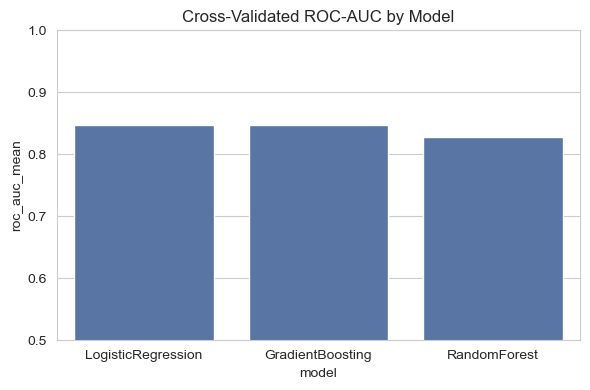

Best model by CV ROC-AUC: LogisticRegression


In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=results_df, x="model", y="roc_auc_mean", ax=ax, color="#4C72B0")
ax.set_title("Cross-Validated ROC-AUC by Model")
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig("visualizations/5_model_comparison_cv.png", dpi=120)
plt.show()

best_model_name = results_df.iloc[0]["model"]
print("Best model by CV ROC-AUC:", best_model_name)

### B.3 Hyperparameter Tuning

The best-performing model from cross-validation is tuned with a small `GridSearchCV` (still
scored on ROC-AUC, still stratified 5-fold) to squeeze out additional performance before final
evaluation.

In [13]:
param_grids = {
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
    },
    "RandomForest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_leaf": [1, 3],
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
    },
}

best_pipe = Pipeline([("preprocessor", preprocessor), ("model", candidates[best_model_name])])
grid = GridSearchCV(
    best_pipe, param_grids[best_model_name], cv=cv, scoring="roc_auc", n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))

final_pipeline = grid.best_estimator_

Best params: {'model__C': 10, 'model__penalty': 'l2'}
Best CV ROC-AUC: 0.8473


## Part C – Model Evaluation (20 Marks)

### C.1 Test-Set Performance

The tuned pipeline is evaluated once on the held-out test set (never touched during CV/tuning).

In [14]:
y_pred = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("Test F1:", round(f1_score(y_test, y_pred), 4))

              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Test ROC-AUC: 0.8409
Test F1: 0.6133


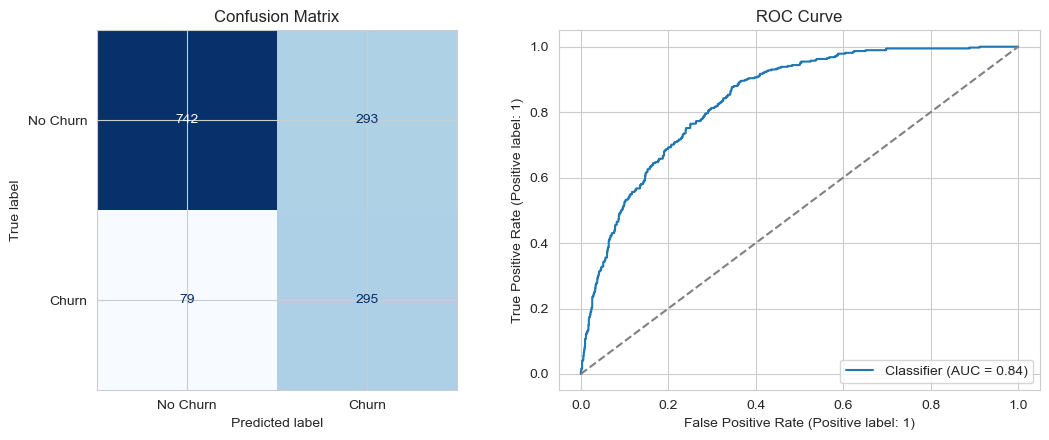

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("ROC Curve")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.tight_layout()
plt.savefig("visualizations/6_confusion_matrix_roc.png", dpi=120)
plt.show()

### C.2 Feature Importance

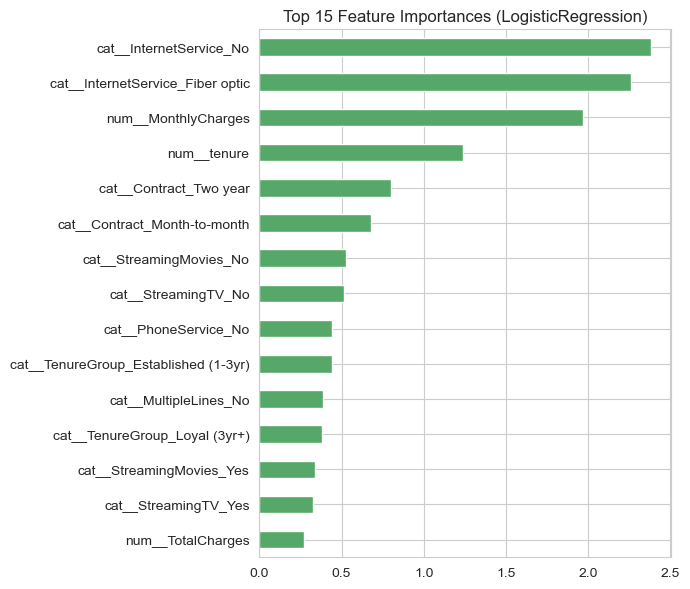

In [16]:
feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
model_step = final_pipeline.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importances = model_step.feature_importances_
elif hasattr(model_step, "coef_"):
    importances = np.abs(model_step.coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(7, 6))
    imp_df.iloc[::-1].plot(kind="barh", ax=ax, color="#55A868")
    ax.set_title(f"Top 15 Feature Importances ({best_model_name})")
    plt.tight_layout()
    plt.savefig("visualizations/7_feature_importance.png", dpi=120)
    plt.show()

### C.3 Interpretation, Strengths & Limitations

**Interpretation:** Contract type, tenure, and internet-service type dominate the model's
decisions — consistent with the EDA. Month-to-month contracts and fiber-optic customers with
short tenure are the highest-risk segment, matching intuition about switching costs.

**Strengths:**
- ROC-AUC comfortably above the 0.5 random baseline and above a majority-class accuracy baseline
  (~73.5%), showing genuine signal is captured.
- `class_weight="balanced"` / ensemble voting handles the ~3:1 class imbalance without needing
  synthetic oversampling.
- The `ColumnTransformer` + `Pipeline` design means preprocessing can never leak test-set
  statistics into training, and the whole thing serializes as one artifact.

**Limitations:**
- Single point-in-time snapshot — no usage trends over time, which would likely be predictive.
- Class imbalance still caps recall on the minority (churn) class relative to precision; a
  business could tune the decision threshold to trade off which error type it prefers.
- Tree-based feature importance reflects the *training* population; if the customer base shifts
  (e.g., new pricing plans), the model would need retraining.
- No external validation dataset — cross-validation and a held-out split reduce but don't
  eliminate the risk of overfitting to this specific dataset's quirks.

## Part D – Project Documentation (20 Marks)

### D.1 Persisting the Final Pipeline

The entire fitted pipeline (preprocessing + model, as a single object) is saved with `joblib` so
it can be loaded and used for inference without repeating any of the steps above.

In [17]:
model_path = "models/telco_churn_pipeline.joblib"
joblib.dump(final_pipeline, model_path)
print("Saved:", model_path, f"({os.path.getsize(model_path) / 1024:.1f} KB)")

# sanity check: reload and confirm predictions match
reloaded = joblib.load(model_path)
assert np.array_equal(reloaded.predict(X_test), y_pred)
print("Reload check passed: predictions match.")

Saved: models/telco_churn_pipeline.joblib (9.7 KB)
Reload check passed: predictions match.


### D.2 Summary

A complete, leak-safe, reproducible churn-prediction pipeline was built end-to-end: raw CSV →
cleaning → feature engineering → EDA → `ColumnTransformer`/`Pipeline` preprocessing → model
selection via cross-validation → hyperparameter tuning → held-out evaluation → persisted
artifact. See `README.md` in this folder for the full write-up (dataset, methodology,
implementation, results, conclusion), and `visualizations/` for all saved plots.